In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/tanlikesmath
/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset
/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images
/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/images


In [3]:
images_fp = "/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/images"

In [4]:
image_names = [
    os.path.basename(file)
    for file in glob.glob(os.path.join(images_fp, "*.jpg"))
]

print("Total Images:", len(image_names))

Total Images: 7389


In [5]:
image_names = [
    os.path.basename(file)
    for file in glob.glob(os.path.join(images_fp, "*.jpg"))
]

print("Total Images:", len(image_names))

Total Images: 7389


In [6]:
#displaying first few images
image_names[:10]

['american_pit_bull_terrier_16.jpg',
 'leonberger_200.jpg',
 'english_cocker_spaniel_35.jpg',
 'Siamese_67.jpg',
 'boxer_77.jpg',
 'saint_bernard_146.jpg',
 'american_bulldog_37.jpg',
 'Sphynx_239.jpg',
 'Egyptian_Mau_164.jpg',
 'Birman_116.jpg']

In [7]:
#Extractin thr gread labels
labels = [
    "_".join(name.split("_")[:-1])
    for name in image_names
]

labels[:10]


['american_pit_bull_terrier',
 'leonberger',
 'english_cocker_spaniel',
 'Siamese',
 'boxer',
 'saint_bernard',
 'american_bulldog',
 'Sphynx',
 'Egyptian_Mau',
 'Birman']

In [8]:
#Encoding the labels
encoder = LabelEncoder()

encoded_labels = encoder.fit_transform(labels)

encoded_labels[:10]

array([13, 25, 18, 10, 16, 30, 12, 11,  5,  2])

In [9]:
#printing the no.of classes
print("Number of Classes:", len(encoder.classes_))

Number of Classes: 37


In [10]:
#Resizing the images
IMAGE_SIZE = (224,224)

features = []
targets = []

In [11]:
print(images_fp)

/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/images


In [12]:
print(len(image_names))

7389


In [13]:
print(image_names[0])

american_pit_bull_terrier_16.jpg


In [14]:
import os

path = os.path.join(images_fp, image_names[0])
print(path)
print(os.path.exists(path))

/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/images/american_pit_bull_terrier_16.jpg
True


In [15]:
img = load_img(path)
print(type(img))
print(img.size)

<class 'PIL.JpegImagePlugin.JpegImageFile'>
(500, 333)


In [16]:
img = img_to_array(img)
print(img.shape)

(333, 500, 3)


In [36]:
img = tf.image.resize(img, (224, 224))
print(img.shape)

(224, 224, 3)


In [37]:
img = img / 255.0
print(img.shape)

(224, 224, 3)


In [38]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [39]:
print(images_fp)

/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/images


In [40]:
print(image_names[0])

path = os.path.join(images_fp, image_names[0])

print(path)

img = load_img(path)

print(img.size)

american_pit_bull_terrier_16.jpg
/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images/images/american_pit_bull_terrier_16.jpg
(500, 333)


In [41]:
features = []
targets = []

for i, (name, label) in enumerate(zip(image_names, encoded_labels)):

    if i % 1000 == 0:
        print(f"Processed {i} images")

    path = os.path.join(images_fp, name)

    img = load_img(path)

    img = img_to_array(img)

    img = tf.image.resize(img, (224,224))

    img = img / 255.0

    features.append(img)

    targets.append(label)

print("Finished Loading Dataset")

Processed 0 images
Processed 1000 images
Processed 2000 images
Processed 3000 images
Processed 4000 images
Processed 5000 images
Processed 6000 images
Processed 7000 images
Finished Loading Dataset


In [42]:
X = np.array(features)

y = np.array(targets)

print(X.shape)

print(y.shape)

(7389, 224, 224, 3)
(7389,)


In [43]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y)

print(y.shape)

(7389, 37)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5911, 224, 224, 3)
(1478, 224, 224, 3)


In [45]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [46]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [47]:
base_model.trainable = False

In [48]:
model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(512, activation='relu'),

    Dropout(0.5),

    Dense(37, activation='softmax')
])

In [49]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 37)             │        18,981 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,932,837 (11.19 MB)

 Trainable params: 674,853 (2.57 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [50]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [61]:
# Train the model
# Make sure your Kaggle accelerator (GPU) is turned on for speed!
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,            # 10 epochs is a good start for transfer learning
    batch_size=32         # Processes 32 images at a time
)


Epoch 1/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.9482 - loss: 0.1471 - val_accuracy: 0.8884 - val_loss: 0.3672
Epoch 2/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9594 - loss: 0.1221 - val_accuracy: 0.8917 - val_loss: 0.3791
Epoch 3/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9609 - loss: 0.1060 - val_accuracy: 0.8843 - val_loss: 0.3961
Epoch 4/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9687 - loss: 0.0908 - val_accuracy: 0.8890 - val_loss: 0.4541
Epoch 5/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9670 - loss: 0.0923 - val_accuracy: 0.8911 - val_loss: 0.3977
Epoch 6/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9707 - loss: 0.0819 - val_accuracy: 0.8775 - val_loss: 0.4290
Epoch 7/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9755 - loss: 0.0656 - val_accuracy: 0.8897 - val_loss: 0.4258
Epoch 8/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9778 - loss: 0.0634 - val_accu

In [62]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8843 - loss: 0.4833
Test Loss: 0.4833
Test Accuracy: 88.43%


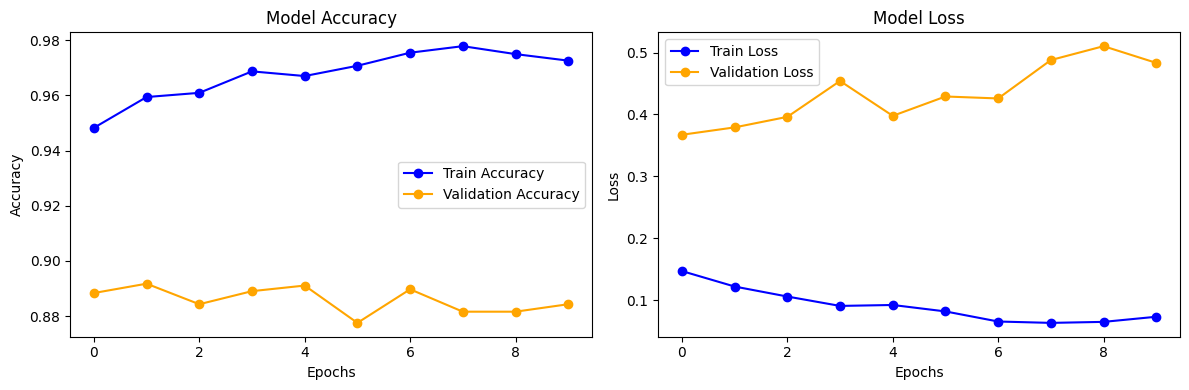

In [63]:
import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy and Loss
plt.figure(figsize=(12, 4))

# 1. Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 2. Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


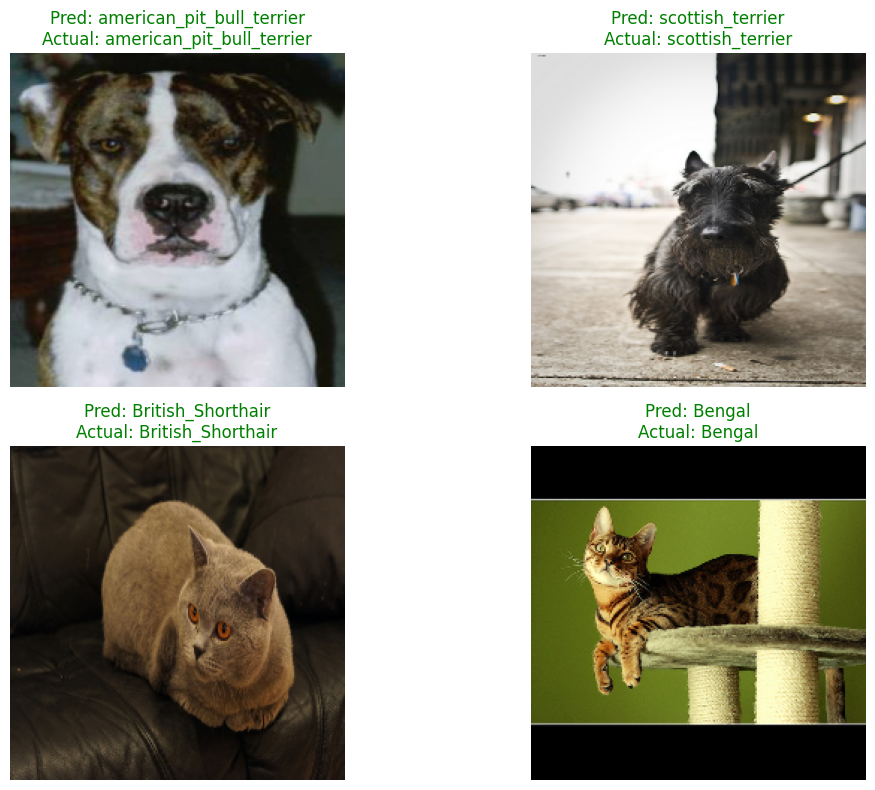

In [64]:
# Get predictions for the test set
predictions = model.predict(X_test)

# Display 4 random images with predicted vs actual labels
plt.figure(figsize=(12, 8))
for i in range(4):
    idx = np.random.randint(0, len(X_test))
    
    # Get the index of the highest probability
    predicted_label_idx = np.argmax(predictions[idx])
    actual_label_idx = np.argmax(y_test[idx])
    
    # Convert index back to original text class name
    pred_name = encoder.classes_[predicted_label_idx]
    actual_name = encoder.classes_[actual_label_idx]
    
    plt.subplot(2, 2, i + 1)
    plt.imshow(X_test[idx])
    
    # Color title green if correct, red if wrong
    title_color = 'green' if pred_name == actual_name else 'red'
    plt.title(f"Pred: {pred_name}\nActual: {actual_name}", color=title_color)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [66]:
# Evaluate the model by passing your test data arrays
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8843 - loss: 0.4833
Test Loss: 0.4833
Test Accuracy: 88.43%


In [67]:
# Save the model architecture and weights together
model.save('oxford_pet_mobilenetv2_model.keras')
print("✅ Model saved successfully in Kaggle Output!")


✅ Model saved successfully in Kaggle Output!


In [68]:
from sklearn.metrics import classification_report

# Get predictions for the whole test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print the report showing precision and recall for your project documentation
print(classification_report(y_true_classes, y_pred_classes, target_names=encoder.classes_))


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
                            precision    recall  f1-score   support

                Abyssinian       0.82      0.90      0.86        40
                    Bengal       0.83      0.85      0.84        40
                    Birman       0.83      0.72      0.77        40
                    Bombay       0.95      0.95      0.95        40
         British_Shorthair       0.70      0.88      0.78        40
              Egyptian_Mau       0.95      0.88      0.91        40
                Maine_Coon       0.77      0.85      0.81        40
                   Persian       0.97      0.72      0.83        40
                   Ragdoll       0.60      0.82      0.69        40
              Russian_Blue       0.87      0.65      0.74        40
                   Siamese       0.92      0.88      0.90        40
                    Sphynx       0.95      1.00      0.98        40
          american_bulldog       0.80      0.93      0.86        40
 americ